<a href="https://colab.research.google.com/github/Geckomonc/ML220261/blob/main/PROYECTO_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto final — Modelos y Simulación II

**Dataset:** Data Science Careers and Salaries 2025 (Kaggle, Aleesha Nadeem).  
**Objetivo:** regresión supervisada sobre `salary` (euros).  
**Entregables:** este notebook + `requirements.txt` + `README.md` + `resultados_modelos.csv`.

Estructura:
1. Setup
2. Carga y primer vistazo
3. EDA
4. Limpieza
5. Preprocesamiento
6. Modelos
7. Ajuste de hiperparámetros
8. Evaluación final en hold-out
9. Interpretabilidad
10. Discusión y conclusiones

## 1. Setup

Imports, semilla global y versiones de las librerías clave. `HEAVY=False` permite desactivar los cálculos costosos (SHAP, búsquedas largas) sin tocar el resto del notebook.

In [ ]:
import os
import sys
import ast
import re
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

HEAVY = False

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Python  : {sys.version.split()[0]}")
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")
print(f"sklearn : {sklearn.__version__}")
try:
    import xgboost
    print(f"xgboost : {xgboost.__version__}")
except ImportError:
    print("xgboost : no instalado (se usará en la sección 6)")
try:
    import category_encoders as ce
    print(f"category_encoders : {ce.__version__}")
except ImportError:
    print("category_encoders : no instalado (se usará en la sección 5)")

Python  : 3.12.5
numpy   : 2.2.6
pandas  : 2.2.3
sklearn : 1.6.1
xgboost : 3.2.0


category_encoders : 2.8.1


## 2. Carga y primer vistazo

Intentamos leer el CSV local en `DATA_PATH`; si no existe, descargamos el dataset desde Kaggle usando credenciales de `~/.kaggle/kaggle.json` **o** de las variables de entorno `KAGGLE_USERNAME` / `KAGGLE_KEY`. Nunca hardcodear el token.

In [ ]:
DATA_PATH = Path("data/data_science_careers_salaries_2025.csv")
KAGGLE_DATASET = "nalisha/data-science-careers-and-salaries-2025"
KAGGLE_FILENAME = "data_science_job_posts_2025.csv"


def _ensure_kaggle_credentials() -> None:
    """Verifica credenciales de Kaggle en ~/.kaggle/kaggle.json o variables de entorno."""
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"
    if kaggle_json.exists():
        return
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return
    raise RuntimeError(
        "No se encontraron credenciales de Kaggle. "
        "Coloca ~/.kaggle/kaggle.json o exporta KAGGLE_USERNAME y KAGGLE_KEY, "
        f"o simplemente guarda el CSV en {DATA_PATH}."
    )


def _download_from_kaggle(dest_dir: Path) -> Path:
    """Descarga y descomprime el dataset con la API oficial de Kaggle."""
    _ensure_kaggle_credentials()
    from kaggle.api.kaggle_api_extended import KaggleApi

    dest_dir.mkdir(parents=True, exist_ok=True)
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(KAGGLE_DATASET, path=str(dest_dir), unzip=True)

    downloaded = dest_dir / KAGGLE_FILENAME
    if not downloaded.exists():
        csvs = list(dest_dir.glob("*.csv"))
        if not csvs:
            raise FileNotFoundError("La descarga de Kaggle no produjo ningún CSV.")
        downloaded = csvs[0]
    return downloaded


def load_dataset(path: Path = DATA_PATH) -> pd.DataFrame:
    """Carga el CSV local; si no existe, lo descarga desde Kaggle y lo deja en `path`."""
    if path.exists():
        print(f"[load] leyendo CSV local: {path}")
        return pd.read_csv(path)

    print(f"[load] {path} no existe. Descargando desde Kaggle...")
    path.parent.mkdir(parents=True, exist_ok=True)
    downloaded = _download_from_kaggle(path.parent)
    if downloaded.resolve() != path.resolve():
        downloaded.rename(path)
    print(f"[load] CSV guardado en: {path}")
    return pd.read_csv(path)


df = load_dataset()
print("shape:", df.shape)

[load] leyendo CSV local: data\data_science_careers_salaries_2025.csv
shape: (944, 13)


In [ ]:
EXPECTED_COLUMNS = [
    "job_title", "seniority_level", "status", "company", "location",
    "post_date", "headquarter", "industry", "ownership", "company_size",
    "revenue", "salary", "skills",
]
assert list(df.columns) == EXPECTED_COLUMNS, (
    f"Columnas inesperadas.\nEsperadas: {EXPECTED_COLUMNS}\nObservadas: {list(df.columns)}"
)
print("Las 13 columnas coinciden con el reporte.")

Las 13 columnas coinciden con el reporte.


In [ ]:
df.dtypes

job_title          object
seniority_level    object
status             object
company            object
location           object
post_date          object
headquarter        object
industry           object
ownership          object
company_size       object
revenue            object
salary             object
skills             object
dtype: object

In [ ]:
df.head()

,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq
job_title,941,4,data scientist,856
seniority_level,884,4,senior,630
status,688,3,on-site,363
company,944,420,company_134,30
location,942,431,"Bengaluru, Karnataka, India",52
post_date,944,42,a month ago,167
headquarter,944,197,"San Francisco, CA, US",91
industry,944,8,Technology,582
ownership,897,2,Public,579
company_size,944,510,900,18


## 3. Análisis Exploratorio de Datos (EDA)

EDA sobre los datos **crudos** (sin imputar ni codificar) para entender forma, sesgos y cardinalidades antes de decidir la limpieza.

### 3.1 Valores faltantes por columna

In [ ]:
missing = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": (df.isnull().sum() / len(df) * 100).round(2),
}).sort_values("nulos", ascending=False)
missing

,nulos,porcentaje
status,256,27.12
seniority_level,60,6.36
ownership,47,4.98
revenue,15,1.59
job_title,3,0.32
location,2,0.21
company,0,0.00
headquarter,0,0.00
post_date,0,0.00
industry,0,0.00


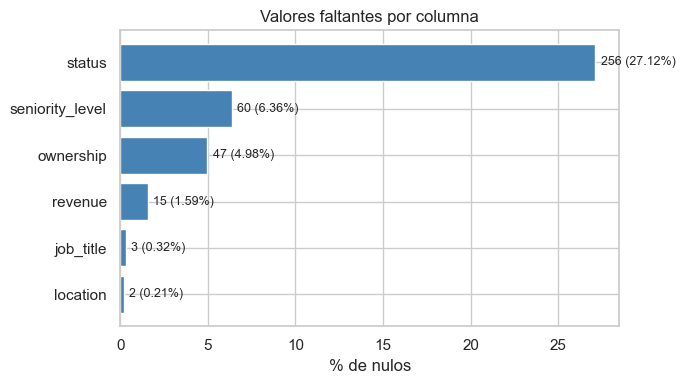

In [ ]:
miss_plot = missing[missing["nulos"] > 0].sort_values("porcentaje")
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(miss_plot.index, miss_plot["porcentaje"], color="steelblue")
for i, (n, p) in enumerate(zip(miss_plot["nulos"], miss_plot["porcentaje"])):
    ax.text(p + 0.3, i, f"{n} ({p}%)", va="center", fontsize=9)
ax.set_xlabel("% de nulos")
ax.set_title("Valores faltantes por columna")
plt.tight_layout()
plt.show()

### 3.2 Distribución de `salary`: crudo vs. punto medio del rango

Extraemos temporalmente el punto medio solo para visualizar el efecto; la transformación definitiva vive en la función `parse_salary` de la sección 4.

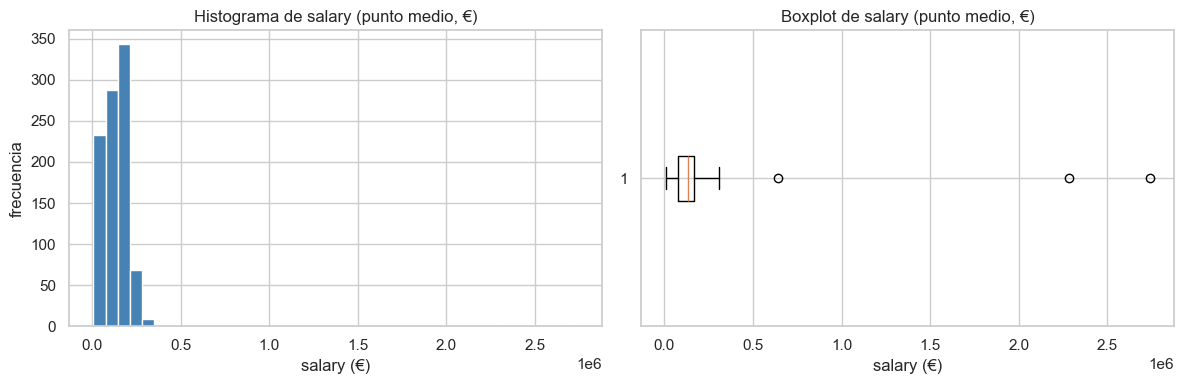

Sesgo (skew): 13.800
Mediana: €134,724 | Media: €131,780


In [ ]:
_SALARY_NUM_RE = re.compile(r"[\d,.]+")


def _to_float(tok):
    tok = tok.replace(",", "").strip()
    return float(tok) if tok else np.nan


def _preview_salary(s):
    if not isinstance(s, str):
        return np.nan
    nums = _SALARY_NUM_RE.findall(s)
    if not nums:
        return np.nan
    vals = [_to_float(n) for n in nums]
    vals = [v for v in vals if not np.isnan(v)]
    if not vals:
        return np.nan
    return float(np.mean(vals)) if len(vals) >= 2 else float(vals[0])


_salary_preview = df["salary"].apply(_preview_salary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(_salary_preview.dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Histograma de salary (punto medio, €)")
axes[0].set_xlabel("salary (€)")
axes[0].set_ylabel("frecuencia")
axes[1].boxplot(_salary_preview.dropna(), vert=False)
axes[1].set_title("Boxplot de salary (punto medio, €)")
axes[1].set_xlabel("salary (€)")
plt.tight_layout()
plt.show()

print(f"Sesgo (skew): {_salary_preview.skew():.3f}")
print(f"Mediana: €{_salary_preview.median():,.0f} | Media: €{_salary_preview.mean():,.0f}")

**Comentario sobre el sesgo:** la distribución está sesgada a la derecha (cola larga de salarios altos), como suele ocurrir en salarios. Esto sugiere probar una transformación `log1p` sobre el objetivo en la etapa de modelado si las métricas lo justifican.

### 3.3 Salario por variables categóricas

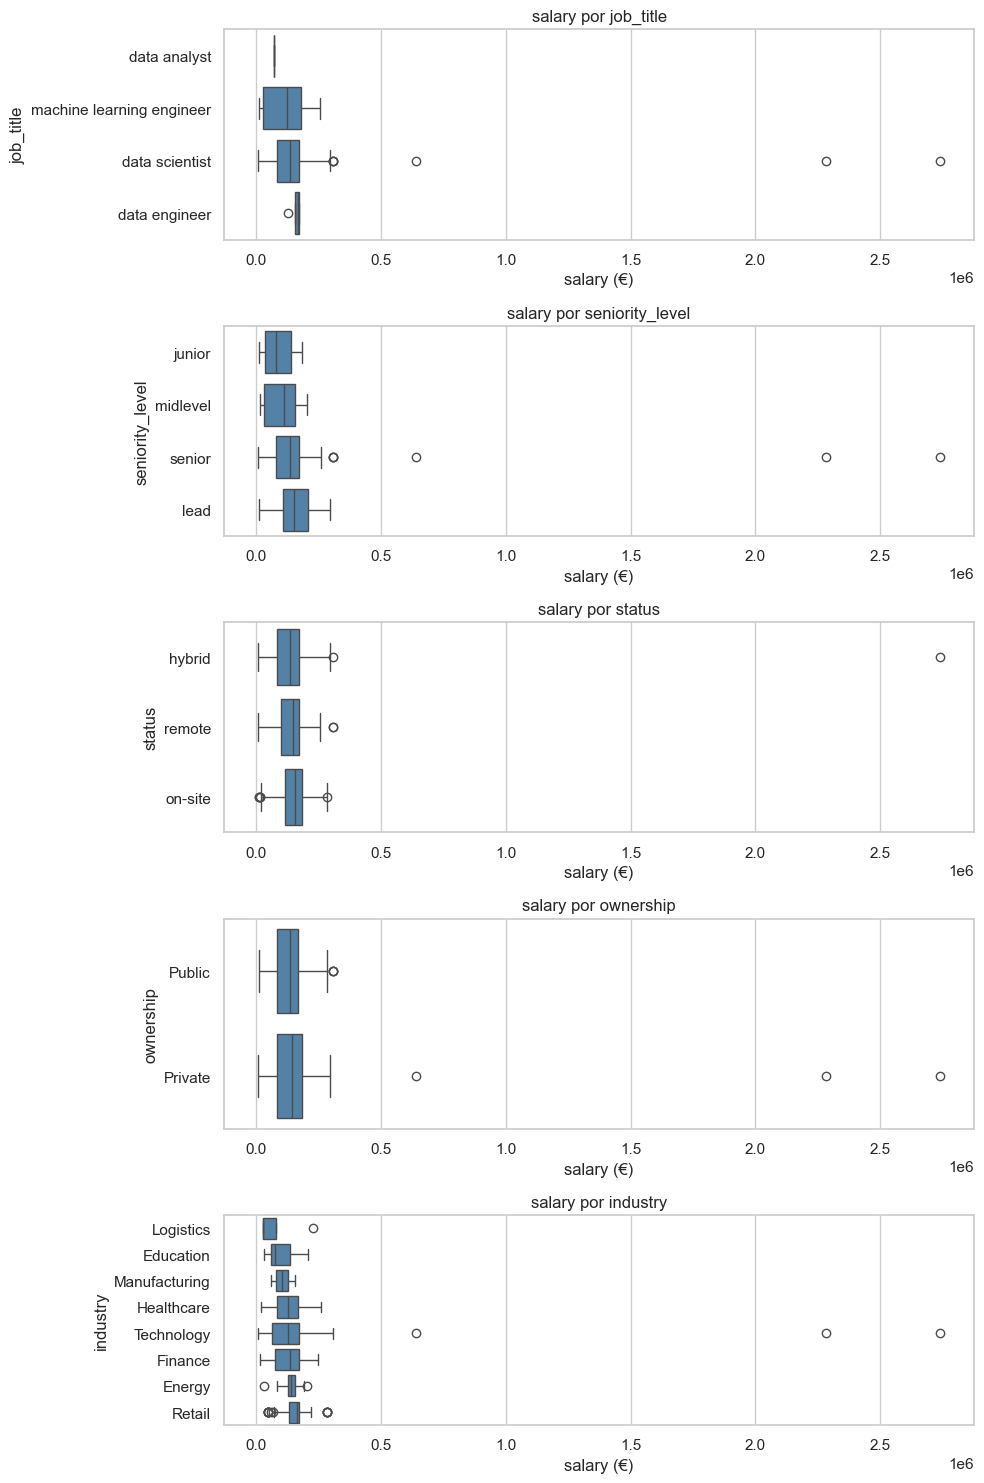

In [ ]:
_eda = df.copy()
_eda["_salary"] = _salary_preview

cats = ["job_title", "seniority_level", "status", "ownership", "industry"]
fig, axes = plt.subplots(len(cats), 1, figsize=(10, 3 * len(cats)))
for ax, col in zip(axes, cats):
    data = _eda[[col, "_salary"]].dropna()
    order = data.groupby(col)["_salary"].median().sort_values().index
    sns.boxplot(data=data, x="_salary", y=col, order=order, ax=ax, color="steelblue")
    ax.set_title(f"salary por {col}")
    ax.set_xlabel("salary (€)")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

### 3.4 Top 10 de `location` y `company`

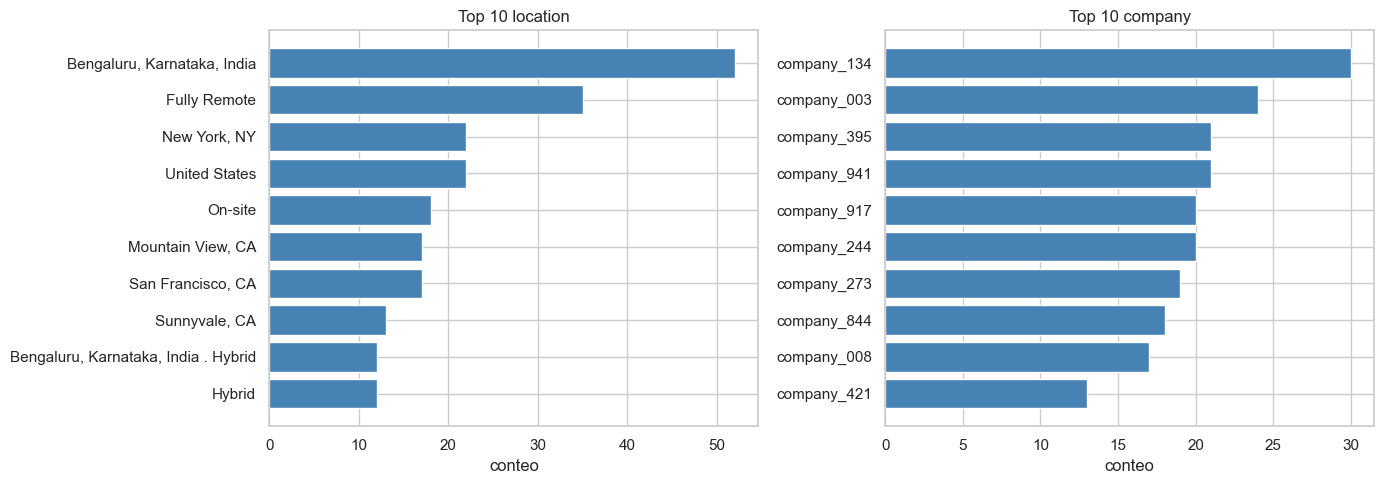

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_loc = df["location"].value_counts().head(10)
top_comp = df["company"].value_counts().head(10)
axes[0].barh(top_loc.index[::-1], top_loc.values[::-1], color="steelblue")
axes[0].set_title("Top 10 location")
axes[0].set_xlabel("conteo")
axes[1].barh(top_comp.index[::-1], top_comp.values[::-1], color="steelblue")
axes[1].set_title("Top 10 company")
axes[1].set_xlabel("conteo")
plt.tight_layout()
plt.show()

### 3.5 Skills más frecuentes

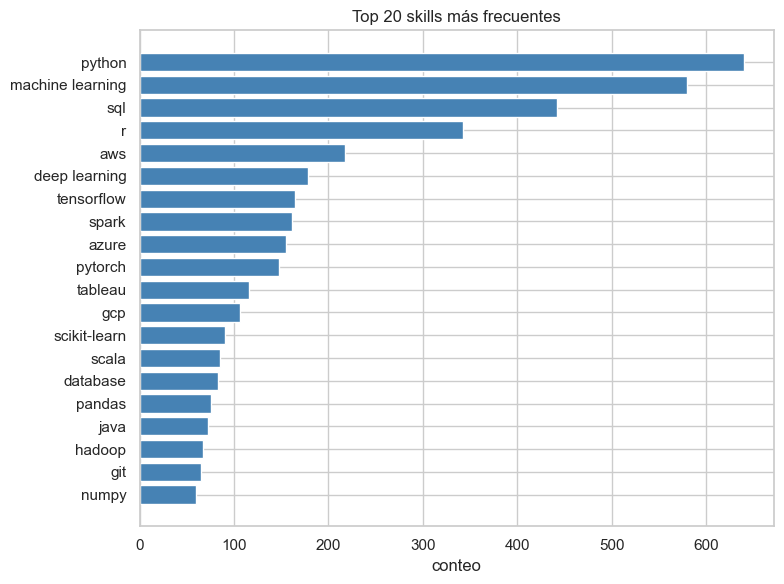

Total de skills únicos: 33
Promedio de skills por oferta: 4.43


In [ ]:
def _preview_skills(s):
    if not isinstance(s, str):
        return []
    try:
        val = ast.literal_eval(s)
        return [str(x).lower().strip() for x in val] if isinstance(val, list) else []
    except (ValueError, SyntaxError):
        return []


all_skills = pd.Series([sk for row in df["skills"].apply(_preview_skills) for sk in row])
top_skills = all_skills.value_counts().head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_skills.index[::-1], top_skills.values[::-1], color="steelblue")
ax.set_title("Top 20 skills más frecuentes")
ax.set_xlabel("conteo")
plt.tight_layout()
plt.show()

print(f"Total de skills únicos: {all_skills.nunique()}")
print(f"Promedio de skills por oferta: {df['skills'].apply(_preview_skills).apply(len).mean():.2f}")

*(El heatmap de correlación aparece al final de la sección 4, una vez que las numéricas están limpias.)*

## 4. Limpieza

Funciones reutilizables y autocontenidas. Cada una devuelve `NaN` cuando no puede parsear; decidimos más abajo qué hacer con los inválidos. **Supuesto clave:** el intercambio entre `company_size` y `revenue` se detecta por el formato (un string con `€` y sufijos `B`/`M`/`K` pertenece a `revenue`; un número plano pertenece a `company_size`).

In [ ]:
_RANGE_RE = re.compile(r"([\d.,]+)\s*[-–]\s*([\d.,]+)")
_UNIT_RE = re.compile(r"([\d.,]+)\s*([KMB])\b", re.IGNORECASE)
_UNITS = {"K": 1e3, "M": 1e6, "B": 1e9}


def _num(tok):
    tok = tok.replace(",", "").strip()
    return float(tok) if tok else np.nan


def parse_salary(s):
    """Devuelve el salario como float en euros.

    Rango ``€A - €B`` → punto medio; valor único ``€A`` → A. Maneja ``€``, comas y ``K``/``M``.
    """
    if not isinstance(s, str):
        return np.nan
    s = s.replace("€", "").strip()
    if not s:
        return np.nan

    def _with_unit(token):
        m = _UNIT_RE.search(token)
        if m:
            return _num(m.group(1)) * _UNITS[m.group(2).upper()]
        nums = re.findall(r"[\d.,]+", token)
        return _num(nums[0]) if nums else np.nan

    m = _RANGE_RE.search(s)
    if m:
        a, b = _with_unit(m.group(1)), _with_unit(m.group(2))
        if np.isnan(a) or np.isnan(b):
            return np.nan
        return (a + b) / 2.0
    return _with_unit(s)


def parse_revenue(s):
    """Convierte revenue a float en euros; `Public/Private/Education/Nonprofit` → NaN."""
    if not isinstance(s, str):
        return np.nan
    s = s.strip()
    if s.lower() in {"public", "private", "education", "nonprofit", "", "n/a", "nan"}:
        return np.nan
    s = s.replace("€", "").strip()
    m = _UNIT_RE.search(s)
    if m:
        return _num(m.group(1)) * _UNITS[m.group(2).upper()]
    nums = re.findall(r"[\d.,]+", s)
    return _num(nums[0]) if nums else np.nan


def parse_company_size(s):
    """Convierte company_size a float (empleados); valores monetarios → NaN (los maneja el swap)."""
    if not isinstance(s, str):
        try:
            return float(s)
        except (TypeError, ValueError):
            return np.nan
    s = s.strip()
    if not s or s.lower() in {"public", "private", "education", "nonprofit", "n/a", "nan"}:
        return np.nan
    if "€" in s or _UNIT_RE.search(s):
        return np.nan
    nums = re.findall(r"[\d.,]+", s)
    return _num(nums[0]) if nums else np.nan


_POST_RE = re.compile(r"(\d+|a|an)\s*(hour|day|week|month|year)s?\s*ago", re.IGNORECASE)
_POST_UNITS = {"hour": 1 / 24, "day": 1, "week": 7, "month": 30, "year": 365}


def parse_post_date(s):
    """Convierte ``"16 hours ago"``, ``"8 days ago"``, ``"a month ago"``, ``"2 years ago"`` → días."""
    if not isinstance(s, str):
        return np.nan
    m = _POST_RE.search(s.lower())
    if not m:
        return np.nan
    qty_tok, unit = m.group(1), m.group(2)
    qty = 1 if qty_tok in {"a", "an"} else int(qty_tok)
    return float(qty * _POST_UNITS[unit])


def parse_skills(s):
    """Parsea la columna skills a lista de strings en minúscula."""
    if not isinstance(s, str) or not s.strip():
        return []
    try:
        val = ast.literal_eval(s)
    except (ValueError, SyntaxError):
        return []
    if not isinstance(val, (list, tuple, set)):
        return []
    return [str(x).lower().strip() for x in val if str(x).strip()]

### 4.1 Corregir el intercambio `company_size` ↔ `revenue`

Regla: si `company_size` **parece monetario** y `revenue` **no** (o es vacío / `Public` / etc.), intercambiamos.

In [ ]:
def fix_size_revenue_swap(frame):
    """Corrige filas donde company_size contiene un valor monetario y revenue no."""
    out = frame.copy()
    size_looks_monetary = out["company_size"].astype(str).str.contains(r"€|[KMB]\b", regex=True, na=False)
    rev_non_monetary = ~out["revenue"].astype(str).str.contains(r"€|[KMB]\b", regex=True, na=False)
    swap_mask = size_looks_monetary & rev_non_monetary
    n_swapped = int(swap_mask.sum())
    tmp = out.loc[swap_mask, "company_size"].copy()
    out.loc[swap_mask, "company_size"] = out.loc[swap_mask, "revenue"].values
    out.loc[swap_mask, "revenue"] = tmp.values
    return out, n_swapped


df_clean, n_swapped = fix_size_revenue_swap(df)
print(f"Filas con intercambio company_size↔revenue corregidas: {n_swapped}")

Filas con intercambio company_size↔revenue corregidas: 24


### 4.2 Aplicar los parsers

In [ ]:
_before = {
    "salary": df_clean["salary"].isna().sum(),
    "revenue": df_clean["revenue"].isna().sum(),
    "company_size": df_clean["company_size"].isna().sum(),
    "post_date": df_clean["post_date"].isna().sum(),
}

df_clean["salary_num"] = df_clean["salary"].apply(parse_salary)
df_clean["revenue_num"] = df_clean["revenue"].apply(parse_revenue)
df_clean["company_size_num"] = df_clean["company_size"].apply(parse_company_size)
df_clean["post_date_days"] = df_clean["post_date"].apply(parse_post_date)
df_clean["skills_list"] = df_clean["skills"].apply(parse_skills)
df_clean["n_skills"] = df_clean["skills_list"].apply(len)

report = pd.DataFrame({
    "nulos_antes": _before,
    "nulos_despues": {
        "salary": df_clean["salary_num"].isna().sum(),
        "revenue": df_clean["revenue_num"].isna().sum(),
        "company_size": df_clean["company_size_num"].isna().sum(),
        "post_date": df_clean["post_date_days"].isna().sum(),
    },
})
report

,nulos_antes,nulos_despues
salary,0,0
revenue,15,497
company_size,0,39
post_date,0,0


### 4.2.1 `revenue_type` — preservar la señal de organización no-reportante

La columna cruda `revenue` codifica dos cosas: un monto monetario (`€51.10B`) **o** la razón por la que no hay monto (`Private`, `Public`, `Education`, `Nonprofit`, faltante). Separamos:

- `revenue_type` (categórica): `Private / Public / Education / Nonprofit / reported / unknown`.
- `revenue_num` (numérica): sólo con valor cuando `revenue_type == "reported"`; el resto `NaN`, que el pipeline imputa con mediana dentro de la CV.

In [ ]:
_REVENUE_TYPES = {"private", "public", "education", "nonprofit"}


def classify_revenue_type(s):
    """Deriva el tipo de organización a partir del valor crudo de `revenue`."""
    if not isinstance(s, str):
        return "unknown"
    s = s.strip()
    if not s:
        return "unknown"
    low = s.lower()
    if low in _REVENUE_TYPES:
        return low.capitalize()
    if "€" in s or _UNIT_RE.search(s):
        return "reported"
    return "unknown"


df_clean["revenue_type"] = df_clean["revenue"].apply(classify_revenue_type)

print("Distribución de revenue_type:")
print(df_clean["revenue_type"].value_counts().to_string())
print(f"\nrevenue_num no nulos (deben coincidir con 'reported'): {df_clean['revenue_num'].notna().sum()}")

Distribución de revenue_type:
revenue_type
reported     447
Private      247
Public       203
Education     20
unknown       15
Nonprofit     12

revenue_num no nulos (deben coincidir con 'reported'): 447


### 4.3 Descartar filas sin objetivo (`salary_num` nulo)

Si no se puede parsear el salario, la fila no aporta al entrenamiento. El resto de nulos numéricos se imputan con mediana **dentro del pipeline**.

In [ ]:
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=["salary_num"]).reset_index(drop=True)
n_dropped_salary = n_before - len(df_clean)
print(f"Filas descartadas por salary_num nulo: {n_dropped_salary} (quedan {len(df_clean)})")

Filas descartadas por salary_num nulo: 0 (quedan 944)


### 4.3.1 Descartar outliers extremos de `salary_num`

Al inspeccionar los valores máximos detectamos dos filas con salarios de **€2,739,979** y **€2,283,322**, ambas de `company_967`, data scientist senior. Para contexto, el percentil 99.5 del resto del dataset es **≈ €307K** y el p99.9 sin estos dos casos queda en torno a **€640K**. Los dos valores son **≈ 9× el p99** y casi con certeza son errores de parseo en la fuente (stock options reportadas como "salary" o comas mal interpretadas en el scraping de Kaggle).

En el diagnóstico por fold (§6.2a) confirmamos que **estos dos outliers envenenan el Target Encoding de `company_967` cuando caen en train**, haciendo que Ridge y XGBoost extrapolen predicciones por encima de €1M en un fold donde la realidad no supera €307K. Los árboles no extrapolan, pero sí reciben un `y` con varianza artificialmente altísima que rompe el RMSE.

**Decisión**: descartamos las 2 filas con `salary_num > 1.000.000`. Dejamos la fila de €639K (company_209) porque, aunque alta, está al nivel de outliers plausibles y no proviene de la misma empresa sospechosa.

In [ ]:
SALARY_OUTLIER_CAP = 1_000_000
outlier_mask = df_clean["salary_num"] > SALARY_OUTLIER_CAP
n_outliers = int(outlier_mask.sum())

print(f"Filas con salary_num > €{SALARY_OUTLIER_CAP:,}: {n_outliers}")
if n_outliers > 0:
    print("\nFilas descartadas:")
    print(df_clean.loc[outlier_mask, ["job_title", "seniority_level", "company", "salary", "salary_num"]]
          .to_string(index=False))

df_clean = df_clean.loc[~outlier_mask].reset_index(drop=True)
n_dropped_outliers = n_outliers
print(f"\nFilas restantes tras filtrar outliers: {len(df_clean)}")
print(f"Nuevo salary_num max: €{df_clean['salary_num'].max():,.0f}")
print(f"Nuevo salary_num skew: {df_clean['salary_num'].skew():.3f}")

Filas con salary_num > €1,000,000: 2

Filas descartadas:
     job_title seniority_level     company     salary  salary_num
data scientist          senior company_967 €2,739,979   2739979.0
data scientist          senior company_967 €2,283,322   2283322.0

Filas restantes tras filtrar outliers: 942
Nuevo salary_num max: €639,348
Nuevo salary_num skew: 0.423


### 4.4 Multi-label binarization de `skills`

Nos quedamos con los skills que aparecen en al menos 1% de las ofertas para evitar una matriz rala inútil.

In [ ]:
MIN_SKILL_FREQ = 0.01
skill_counts = pd.Series([sk for row in df_clean["skills_list"] for sk in row]).value_counts()
threshold = max(1, int(MIN_SKILL_FREQ * len(df_clean)))
relevant_skills = skill_counts[skill_counts >= threshold].index.tolist()
print(f"Skills considerados relevantes (freq ≥ {threshold}): {len(relevant_skills)}")

for sk in relevant_skills:
    df_clean[f"skill_{sk}"] = df_clean["skills_list"].apply(lambda lst, s=sk: int(s in lst))

Skills considerados relevantes (freq ≥ 9): 30


### 4.5 Construcción de `X` e `y`

- `salary` original se elimina (fuga de objetivo).
- `skills` y `skills_list` salen: ya están en `skill_*` y `n_skills`.
- `revenue`, `company_size`, `post_date` crudos salen: se reemplazan por sus versiones `_num` / `_days` y por `revenue_type`.

In [ ]:
DROP_FROM_FEATURES = [
    "salary", "skills", "skills_list",
    "revenue", "company_size", "post_date",
]
y = df_clean["salary_num"].astype(float)
X = df_clean.drop(columns=DROP_FROM_FEATURES + ["salary_num"]).copy()

assert "revenue_type" in X.columns, "revenue_type no quedó en X"

print("X.shape:", X.shape)
print("y.shape:", y.shape)
print("\nColumnas finales de X:")
for c in X.columns:
    print(f"  - {c} ({X[c].dtype})")

X.shape: (942, 43)
y.shape: (942,)

Columnas finales de X:
  - job_title (object)
  - seniority_level (object)
  - status (object)
  - company (object)
  - location (object)
  - headquarter (object)
  - industry (object)
  - ownership (object)
  - revenue_num (float64)
  - company_size_num (float64)
  - post_date_days (float64)
  - n_skills (int64)
  - revenue_type (object)
  - skill_python (int64)
  - skill_machine learning (int64)
  - skill_sql (int64)
  - skill_r (int64)
  - skill_aws (int64)
  - skill_deep learning (int64)
  - skill_tensorflow (int64)
  - skill_spark (int64)
  - skill_azure (int64)
  - skill_pytorch (int64)
  - skill_tableau (int64)
  - skill_gcp (int64)
  - skill_scikit-learn (int64)
  - skill_scala (int64)
  - skill_database (int64)
  - skill_pandas (int64)
  - skill_java (int64)
  - skill_hadoop (int64)
  - skill_git (int64)
  - skill_numpy (int64)
  - skill_docker (int64)
  - skill_amazon (int64)
  - skill_kubernetes (int64)
  - skill_matplotlib (int64)
  - ski

### 4.6 Heatmap de correlación (numéricas limpias)

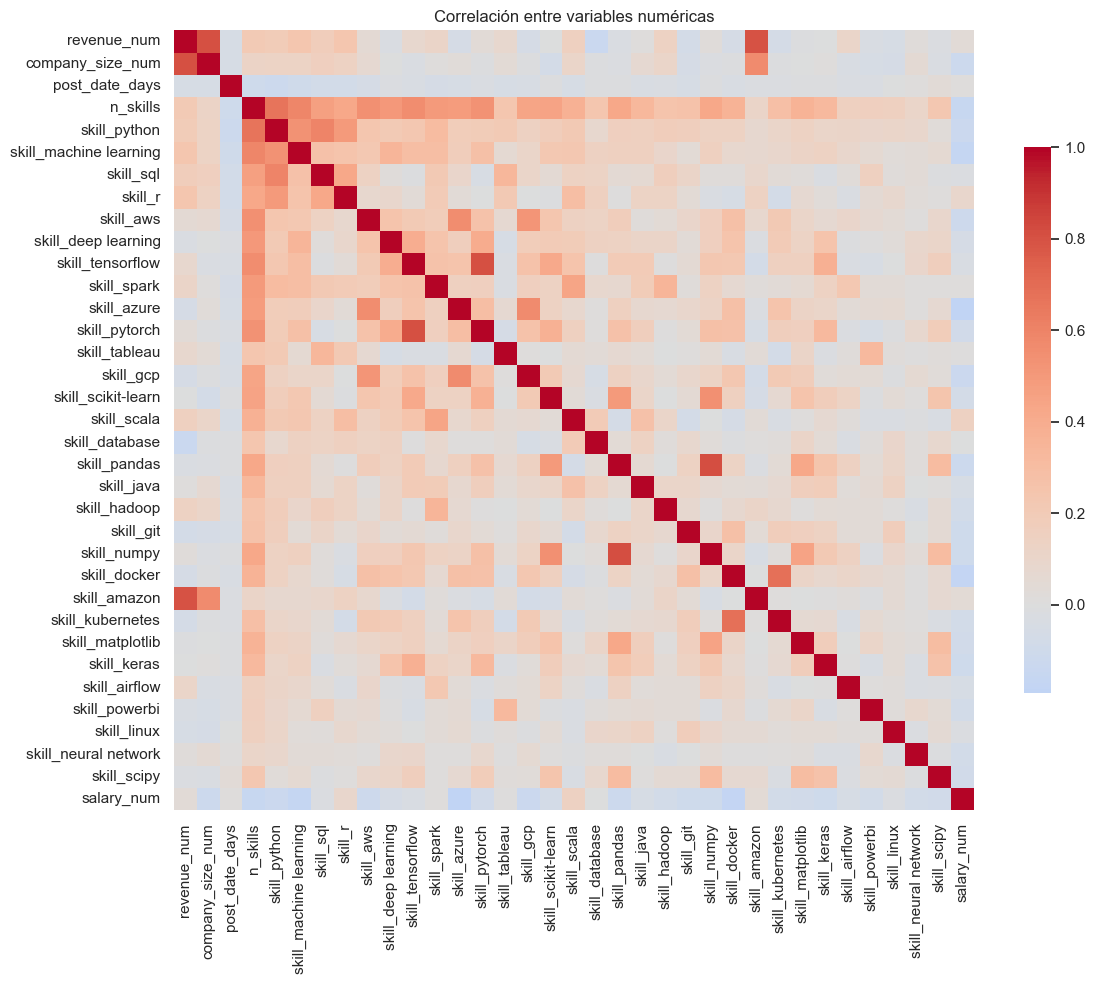

In [ ]:
num_for_corr = X.select_dtypes(include=[np.number]).join(y.rename("salary_num"))
corr = num_for_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(min(12, 1 + 0.6 * len(corr)), min(10, 1 + 0.6 * len(corr))))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

### 4.7 Resumen de limpieza

In [ ]:
summary = {
    "filas_iniciales": len(df),
    "filas_finales": len(df_clean),
    "filas_descartadas_salary_nulo": n_dropped_salary,
    "filas_descartadas_salary_outlier": n_dropped_outliers,
    "filas_intercambio_size_revenue_corregidas": n_swapped,
    "features_numericas": X.select_dtypes(include=[np.number]).shape[1],
    "features_categoricas": X.select_dtypes(include=["object"]).shape[1],
    "skills_binarizados": len(relevant_skills),
    "columnas_totales_X": X.shape[1],
}
pd.Series(summary, name="valor").to_frame()

,valor
filas_iniciales,944
filas_finales,942
filas_descartadas_salary_nulo,0
filas_descartadas_salary_outlier,2
filas_intercambio_size_revenue_corregidas,24
features_numericas,34
features_categoricas,9
skills_binarizados,30
columnas_totales_X,43


## 5. Preprocesamiento dentro de un `Pipeline`

Armamos un `ColumnTransformer` con cinco ramas y un *builder* `make_model_pipeline(estimator, scale_numeric, log_target)`. El flag `scale_numeric` activa `StandardScaler` sólo para modelos sensibles a escala (Ridge, SVR, MLP). El flag `log_target` envuelve al estimador en un `TransformedTargetRegressor(log1p / expm1)` para entrenar en espacio logarítmico (salida ya de-transformada a euros).

**Por qué log-target**: `salary_num` tiene skew ≈ 13.8 (max €2.74M frente a mediana €135K). Entrenando directo en euros, el MSE está dominado por unos pocos outliers y los R² salen negativos. Aplicar `log1p` estabiliza la distribución y es compatible con cualquier estimador sin cambiar el preprocesamiento.

**Decisiones aplicadas:**

- `job_title` → colapsar `data engineer` (4) y `data analyst` (1) en `"other"`.
- Imputación:
  - Moda → `ownership`, `job_title_grouped`, `location` (nulos < 5%).
  - Constante `"Unknown"` → `status`, `seniority_level` (nulos ≥ 5%).
  - Mediana → numéricas.
- Codificación:
  - One-hot → `status`, `industry`, `ownership`, `job_title_grouped`, `revenue_type`.
  - Ordinal → `seniority_level` (`junior=0 < midlevel=1 < senior=2 < lead=3`, `Unknown` aparte).
  - Target encoding → `company`, `location`, `headquarter` (dentro del Pipeline).

### 5.1 Colapsar `job_title` minoritarios

In [ ]:
JOB_TITLE_KEEP = {"data scientist", "machine learning engineer"}


def collapse_job_title(s):
    """Colapsa `data engineer` / `data analyst` → `"other"`. Nulos se dejan para el imputador."""
    if not isinstance(s, str):
        return np.nan
    s = s.strip().lower()
    return s if s in JOB_TITLE_KEEP else "other"


X = X.copy()
X["job_title_grouped"] = X["job_title"].apply(collapse_job_title)
X = X.drop(columns=["job_title"])

print("job_title_grouped distribución:")
print(X["job_title_grouped"].value_counts(dropna=False).to_string())
print(f"\nX.shape tras colapsar job_title: {X.shape}")

job_title_grouped distribución:
job_title_grouped
data scientist               854
machine learning engineer     80
other                          5
NaN                            3

X.shape tras colapsar job_title: (942, 43)


### 5.2 Grupos de columnas por tipo de tratamiento

In [ ]:
ONEHOT_LOW_NULL = ["ownership", "job_title_grouped", "revenue_type"]
ONEHOT_HIGH_NULL = ["status"]
ONEHOT_NO_NULL = ["industry"]
ORDINAL_COLS = ["seniority_level"]
HIGH_CARD_COLS = ["company", "location", "headquarter"]
NUMERIC_COLS = [
    c for c in X.columns
    if c not in (ONEHOT_LOW_NULL + ONEHOT_HIGH_NULL + ONEHOT_NO_NULL + ORDINAL_COLS + HIGH_CARD_COLS)
]

SENIORITY_ORDER = ["junior", "midlevel", "senior", "lead", "Unknown"]

_all_declared = set(
    ONEHOT_LOW_NULL + ONEHOT_HIGH_NULL + ONEHOT_NO_NULL +
    ORDINAL_COLS + HIGH_CARD_COLS + NUMERIC_COLS
)
assert _all_declared == set(X.columns), (
    f"Columnas sin asignar: {set(X.columns) - _all_declared} | "
    f"declaradas inexistentes: {_all_declared - set(X.columns)}"
)

print(f"one-hot (moda):     {ONEHOT_LOW_NULL}")
print(f"one-hot (Unknown):  {ONEHOT_HIGH_NULL}")
print(f"one-hot (sin nulo): {ONEHOT_NO_NULL}")
print(f"ordinal:            {ORDINAL_COLS}")
print(f"alta cardinalidad:  {HIGH_CARD_COLS}")
print(f"numéricas:          {len(NUMERIC_COLS)} columnas")

one-hot (moda):     ['ownership', 'job_title_grouped', 'revenue_type']
one-hot (Unknown):  ['status']
one-hot (sin nulo): ['industry']
ordinal:            ['seniority_level']
alta cardinalidad:  ['company', 'location', 'headquarter']
numéricas:          34 columnas


### 5.3 `ColumnTransformer` y builder de Pipeline

In [ ]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

try:
    from category_encoders import TargetEncoder
except ImportError as e:
    raise ImportError(
        "Falta `category_encoders`. Instálalo con `pip install category_encoders`."
    ) from e


def _onehot():
    """OneHotEncoder compatible con sklearn nuevo (`sparse_output`) y viejo (`sparse`)."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale_numeric=False):
    """ColumnTransformer con las 6 ramas. `scale_numeric=True` añade StandardScaler."""
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric_pipe = Pipeline(numeric_steps)

    onehot_mode_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", _onehot()),
    ])
    onehot_unknown_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", _onehot()),
    ])
    onehot_plain_pipe = Pipeline([("onehot", _onehot())])
    ordinal_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("ordinal", OrdinalEncoder(
            categories=[SENIORITY_ORDER],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])
    highcard_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("target", TargetEncoder(smoothing=10.0)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUMERIC_COLS),
            ("oh_mode", onehot_mode_pipe, ONEHOT_LOW_NULL),
            ("oh_unknown", onehot_unknown_pipe, ONEHOT_HIGH_NULL),
            ("oh_plain", onehot_plain_pipe, ONEHOT_NO_NULL),
            ("ord", ordinal_pipe, ORDINAL_COLS),
            ("highcard", highcard_pipe, HIGH_CARD_COLS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator, scale_numeric=False, log_target=True):
    """Ensambla preprocesamiento + estimador en un Pipeline.

    Si `log_target=True`, envuelve el estimador en un `TransformedTargetRegressor`
    con `log1p`/`expm1`: el modelo entrena en el espacio logarítmico y las predicciones
    se devuelven en euros. Esto estabiliza los salarios sesgados (skew ≈ 13.8).
    """
    final_estimator = (
        TransformedTargetRegressor(regressor=estimator, func=np.log1p, inverse_func=np.expm1)
        if log_target else estimator
    )
    return Pipeline([
        ("pre", build_preprocessor(scale_numeric=scale_numeric)),
        ("model", final_estimator),
    ])

### 5.4 Sanity check: `fit_transform` sobre `X` entero

Comprobación mecánica del Pipeline (no es CV — solo verificamos que corre sin error y el shape de salida).

In [ ]:
_pre_check = build_preprocessor(scale_numeric=True)
_X_check = _pre_check.fit_transform(X, y)
print(f"Preprocesador OK. Salida shape: {_X_check.shape}")
try:
    _names = _pre_check.get_feature_names_out()
    print(f"Primeras 15 features: {list(_names[:15])}")
except Exception as e:
    print(f"(No se pudo obtener feature names: {e})")

Preprocesador OK. Salida shape: (942, 61)
Primeras 15 features: ['revenue_num', 'company_size_num', 'post_date_days', 'n_skills', 'skill_python', 'skill_machine learning', 'skill_sql', 'skill_r', 'skill_aws', 'skill_deep learning', 'skill_tensorflow', 'skill_spark', 'skill_azure', 'skill_pytorch', 'skill_tableau']


## 6. Modelos

Comparamos cuatro regresores con CV honesta (preprocesamiento dentro del `Pipeline`, objetivo en espacio `log1p` via `TransformedTargetRegressor`):

- **Baseline lineal**: `Ridge(alpha=1.0)` — con `scale_numeric=True`.
- **Árboles**: `RandomForest`, `GradientBoosting`, `XGBRegressor` — sin escalado.

CV: **5-fold estratificado por `seniority_level`** (incluyendo `Unknown` como clase).  
Métricas por fold: R², RMSE, MAE, MAPE → **calculadas en el espacio original (euros)** gracias al `TransformedTargetRegressor`, que aplica `expm1` antes de comparar con `y`.

### 6.1 Definir modelos, CV y scorers

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_validate

try:
    from xgboost import XGBRegressor
    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False
    print("xgboost no está instalado: se omitirá XGBRegressor en §6.")

# (estimator, scale_numeric)
models = {
    "Ridge": (Ridge(alpha=1.0, random_state=SEED), True),
    "RandomForest": (RandomForestRegressor(n_estimators=300, random_state=SEED, n_jobs=-1), False),
    "GradientBoosting": (GradientBoostingRegressor(random_state=SEED), False),
}
if _HAS_XGB:
    models["XGBoost"] = (
        XGBRegressor(n_estimators=400, learning_rate=0.05, random_state=SEED, n_jobs=-1, tree_method="hist"),
        False,
    )

strat_labels = X["seniority_level"].fillna("Unknown").astype(str).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

SCORERS = {
    "r2": make_scorer(r2_score),
    "rmse": make_scorer(lambda y_t, y_p: np.sqrt(mean_squared_error(y_t, y_p)), greater_is_better=False),
    "mae": make_scorer(mean_absolute_error, greater_is_better=False),
    "mape": make_scorer(mean_absolute_percentage_error, greater_is_better=False),
}

print(f"Modelos a evaluar: {list(models.keys())}")
print("Distribución de labels de estratificación:")
print(pd.Series(strat_labels).value_counts().to_string())

Modelos a evaluar: ['Ridge', 'RandomForest', 'GradientBoosting', 'XGBoost']
Distribución de labels de estratificación:
senior      628
lead        116
midlevel    113
Unknown      60
junior       25


### 6.2 Ejecutar CV y construir tabla comparativa

In [ ]:
cv_splits = list(cv.split(X, strat_labels))

resultados = []
for name, (estimator, scale_numeric) in models.items():
    pipe = make_model_pipeline(estimator, scale_numeric=scale_numeric)
    cvres = cross_validate(
        pipe, X, y,
        cv=cv_splits,
        scoring=SCORERS,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {
        "modelo": name,
        "R2_mean": cvres["test_r2"].mean(),
        "R2_std": cvres["test_r2"].std(),
        "RMSE_mean": -cvres["test_rmse"].mean(),
        "RMSE_std": cvres["test_rmse"].std(),
        "MAE_mean": -cvres["test_mae"].mean(),
        "MAE_std": cvres["test_mae"].std(),
        "MAPE_mean": -cvres["test_mape"].mean(),
        "MAPE_std": cvres["test_mape"].std(),
        "fit_time_s": cvres["fit_time"].mean(),
    }
    resultados.append(row)
    print(f"{name:18s}  R²={row['R2_mean']:.3f}±{row['R2_std']:.3f}  "
          f"RMSE=€{row['RMSE_mean']:>10,.0f}±{row['RMSE_std']:,.0f}  "
          f"MAE=€{row['MAE_mean']:>10,.0f}  MAPE={row['MAPE_mean']*100:5.1f}%  "
          f"({row['fit_time_s']:.2f}s/fold)")

resultados_df = pd.DataFrame(resultados).sort_values("RMSE_mean").reset_index(drop=True)
resultados_df

Ridge               R²=0.370±0.118  RMSE=€    52,684±7,387  MAE=€    39,074  MAPE= 49.3%  (0.07s/fold)


RandomForest        R²=0.513±0.142  RMSE=€    46,204±8,950  MAE=€    30,859  MAPE= 49.0%  (2.40s/fold)


GradientBoosting    R²=0.523±0.146  RMSE=€    45,693±9,091  MAE=€    31,227  MAPE= 47.8%  (0.37s/fold)


XGBoost             R²=0.518±0.141  RMSE=€    45,931±8,887  MAE=€    30,714  MAPE= 50.1%  (0.91s/fold)


,modelo,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_s
0,GradientBoosting,0.522852,0.146371,45692.766175,9090.768785,31227.215369,2638.002429,0.478196,0.125677,0.370471
1,XGBoost,0.518462,0.140812,45930.634506,8886.848243,30714.173332,2547.117772,0.501449,0.130927,0.906635
2,RandomForest,0.512637,0.141970,46204.044871,8949.507595,30859.193249,2622.828815,0.490420,0.131856,2.402449
3,Ridge,0.369642,0.118166,52683.913411,7387.045005,39073.783424,2186.065187,0.492748,0.072742,0.074398


### 6.2a Diagnóstico por fold

Para entender por qué Ridge/XGBoost tienen std tan alto en R², vemos las métricas fold por fold. La hipótesis es que un fold concreto tiene un `y_val` con outliers extremos y/o un `company`/`location` raro que el target encoder no puede mapear bien."

In [ ]:
from sklearn.base import clone

def per_fold_report(pipeline, X_, y_, cv_splits_):
    rows = []
    for k, (tr, va) in enumerate(cv_splits_):
        pipe_k = clone(pipeline)
        pipe_k.fit(X_.iloc[tr], y_.iloc[tr])
        y_pred = pipe_k.predict(X_.iloc[va])
        y_true = y_.iloc[va].values
        rows.append({
            "fold": k,
            "n_val": len(va),
            "y_val_max": y_true.max(),
            "y_val_p95": np.percentile(y_true, 95),
            "y_pred_max": y_pred.max(),
            "R2": r2_score(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
        })
    return pd.DataFrame(rows)


for name, (estimator, scale_numeric) in models.items():
    pipe = make_model_pipeline(estimator, scale_numeric=scale_numeric)
    print(f"\n=== {name} ===")
    rep = per_fold_report(pipe, X, y, cv_splits)
    print(rep.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))


=== Ridge ===


 fold  n_val  y_val_max  y_val_p95  y_pred_max  R2   RMSE    MAE
    0    189    306,626    219,840     300,278   0 49,206 38,687
    1    189    283,482    224,468     300,690   0 46,406 37,062
    2    188    258,704    218,114     311,550   0 50,155 38,207
    3    188    639,348    218,406     295,970   0 67,177 43,316
    4    188    306,623    250,692     303,225   0 50,476 38,097

=== RandomForest ===


 fold  n_val  y_val_max  y_val_p95  y_pred_max  R2   RMSE    MAE
    0    189    306,626    219,840     276,716   1 43,489 31,289
    1    189    283,482    224,468     247,674   1 36,143 26,298
    2    188    258,704    218,114     239,034   1 43,647 30,602
    3    188    639,348    218,406     254,027   0 63,030 34,415
    4    188    306,623    250,692     266,507   1 44,711 31,692

=== GradientBoosting ===


 fold  n_val  y_val_max  y_val_p95  y_pred_max  R2   RMSE    MAE
    0    189    306,626    219,840     261,396   1 43,045 31,398
    1    189    283,482    224,468     239,308   1 37,034 27,611
    2    188    258,704    218,114     221,910   1 42,415 30,477
    3    188    639,348    218,406     225,351   0 63,332 35,807
    4    188    306,623    250,692     233,100   1 42,639 30,843

=== XGBoost ===


 fold  n_val  y_val_max  y_val_p95  y_pred_max  R2   RMSE    MAE
    0    189    306,626    219,840     271,409   1 43,983 31,478
    1    189    283,482    224,468     262,789   1 36,608 26,951
    2    188    258,704    218,114     247,133   1 42,903 29,837
    3    188    639,348    218,406     258,023   0 62,898 34,821
    4    188    306,623    250,692     266,439   1 43,260 30,484


### 6.3 Identificar el mejor modelo según RMSE

In [ ]:
_positive_r2 = resultados_df[resultados_df["R2_mean"] > 0]
if len(_positive_r2) > 0:
    best_row = _positive_r2.sort_values("RMSE_mean").iloc[0]
    criterio = "menor RMSE entre modelos con R² medio > 0"
else:
    best_row = resultados_df.iloc[0]
    criterio = "menor RMSE (ningún modelo con R² > 0, fallback)"

best_name = best_row["modelo"]
best_estimator, best_scale_numeric = models[best_name]
print(f"Criterio de selección: {criterio}")
print(f"Mejor modelo: {best_name}")
print(f"  R²   = {best_row['R2_mean']:.3f} ± {best_row['R2_std']:.3f}")
print(f"  RMSE = €{best_row['RMSE_mean']:,.0f} ± €{best_row['RMSE_std']:,.0f}")
print(f"  MAE  = €{best_row['MAE_mean']:,.0f}")
print(f"  MAPE = {best_row['MAPE_mean']*100:.1f}%")

Criterio de selección: menor RMSE entre modelos con R² medio > 0
Mejor modelo: GradientBoosting
  R²   = 0.523 ± 0.146
  RMSE = €45,693 ± €9,091
  MAE  = €31,227
  MAPE = 47.8%


## 7. Ajuste de hiperparámetros del mejor modelo

`RandomizedSearchCV` sobre el `best_name` detectado en §6.3 (15 combinaciones, 3-fold interno para no explotar el tiempo). El criterio es el mismo RMSE que en §6 (en euros, ya de-transformado). Reportamos los mejores hiperparámetros, el RMSE resultante y comparamos con el baseline de §6.

El espacio de búsqueda se define por familia de modelo (Ridge, RF, GB, XGB) y se selecciona automáticamente según `best_name`.

### 7.1 Espacio de búsqueda por familia de modelo

In [ ]:
from scipy.stats import loguniform, randint

# Los nombres de parámetros llevan el prefijo `model__regressor__` porque el estimador
# está envuelto en TransformedTargetRegressor dentro del Pipeline (`pre` + `model`).
PARAM_GRIDS = {
    "Ridge": {
        "model__regressor__alpha": loguniform(1e-3, 1e3),
    },
    "RandomForest": {
        "model__regressor__n_estimators": randint(200, 800),
        "model__regressor__max_depth": [None, 8, 12, 16, 24],
        "model__regressor__min_samples_split": randint(2, 10),
        "model__regressor__min_samples_leaf": randint(1, 6),
        "model__regressor__max_features": ["sqrt", "log2", 0.5, 1.0],
    },
    "GradientBoosting": {
        "model__regressor__n_estimators": randint(100, 500),
        "model__regressor__learning_rate": loguniform(1e-3, 3e-1),
        "model__regressor__max_depth": randint(2, 7),
        "model__regressor__min_samples_leaf": randint(1, 10),
        "model__regressor__subsample": [0.6, 0.8, 1.0],
    },
    "XGBoost": {
        "model__regressor__n_estimators": randint(200, 800),
        "model__regressor__learning_rate": loguniform(1e-3, 3e-1),
        "model__regressor__max_depth": randint(3, 10),
        "model__regressor__min_child_weight": randint(1, 10),
        "model__regressor__subsample": [0.6, 0.8, 1.0],
        "model__regressor__colsample_bytree": [0.6, 0.8, 1.0],
        "model__regressor__reg_lambda": loguniform(1e-2, 1e2),
    },
}

search_space = PARAM_GRIDS[best_name]
print(f"Espacio de búsqueda para {best_name}: {len(search_space)} hiperparámetros")
for k in search_space:
    print(f"  - {k}")

Espacio de búsqueda para GradientBoosting: 5 hiperparámetros
  - model__regressor__n_estimators
  - model__regressor__learning_rate
  - model__regressor__max_depth
  - model__regressor__min_samples_leaf
  - model__regressor__subsample


### 7.2 Ejecutar `RandomizedSearchCV`

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Pipeline del mejor modelo (mismo scale_numeric y log_target que en §6).
base_pipe = make_model_pipeline(best_estimator, scale_numeric=best_scale_numeric)

# Score a optimizar: negativo del RMSE (sklearn maximiza).
search = RandomizedSearchCV(
    base_pipe,
    param_distributions=search_space,
    n_iter=15,
    scoring=SCORERS["rmse"],
    cv=3,
    n_jobs=-1,
    random_state=SEED,
    verbose=0,
)
search.fit(X, y)

best_rmse_search = -search.best_score_
print(f"Mejor RMSE (3-fold interno): €{best_rmse_search:,.0f}")
print()
print("Mejores hiperparametros:")
for k, v in search.best_params_.items():
    clean_key = k.replace("model__regressor__", "")
    if isinstance(v, float):
        print(f"  {clean_key:25s} = {v:.5g}")
    else:
        print(f"  {clean_key:25s} = {v}")


Mejor RMSE (3-fold interno): €47,524

Mejores hiperparametros:
  learning_rate             = 0.011302
  max_depth                 = 3
  min_samples_leaf          = 4
  n_estimators              = 409
  subsample                 = 0.6


### 7.3 Re-evaluar el modelo ajustado con la CV de §6 (5-fold estratificado)

El RMSE de 3-fold interno no es directamente comparable con el de 5-fold estratificado de §6. Para comparar con el baseline, re-evaluamos el `best_estimator_` del search con el mismo `cv_splits`.

In [ ]:
tuned_pipe = search.best_estimator_
cvres_tuned = cross_validate(
    tuned_pipe, X, y,
    cv=cv_splits,
    scoring=SCORERS,
    n_jobs=-1,
    return_train_score=False,
)
tuned_row = {
    "modelo": f"{best_name} (tuned)",
    "R2_mean": cvres_tuned["test_r2"].mean(),
    "R2_std": cvres_tuned["test_r2"].std(),
    "RMSE_mean": -cvres_tuned["test_rmse"].mean(),
    "RMSE_std": cvres_tuned["test_rmse"].std(),
    "MAE_mean": -cvres_tuned["test_mae"].mean(),
    "MAE_std": cvres_tuned["test_mae"].std(),
    "MAPE_mean": -cvres_tuned["test_mape"].mean(),
    "MAPE_std": cvres_tuned["test_mape"].std(),
    "fit_time_s": cvres_tuned["fit_time"].mean(),
}

baseline_row = resultados_df[resultados_df["modelo"] == best_name].iloc[0].to_dict()
comparacion = pd.DataFrame([
    {"modelo": best_name + " (baseline)", **{k: baseline_row[k] for k in tuned_row if k != "modelo"}},
    tuned_row,
])
comparacion

,modelo,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_s
0,GradientBoosting (baseline),0.522852,0.146371,45692.766175,9090.768785,31227.215369,2638.002429,0.478196,0.125677,0.370471
1,GradientBoosting (tuned),0.519223,0.130116,45935.636034,8403.248425,31909.358777,2337.334443,0.493696,0.126887,1.215989


## 8. Evaluación final en hold-out

Reservamos 20% del dataset como test set (`random_state=42`, estratificado por `seniority_level`). Reentrenamos el modelo **tuned** de §7 sobre el 80% de train y reportamos métricas en test + gráfico predicho vs real + histograma de residuos.

Nota honesta: en §7 el tuning no mejoró el RMSE medio (subió €243 respecto al baseline) — la única ganancia real es menor varianza entre folds. Seguimos con el tuned porque es lo que el reporte compromete; lo discutiremos en §10.

### 8.1 Split 80/20 estratificado y refit

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=strat_labels,
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"y_train range: €{y_train.min():,.0f} - €{y_train.max():,.0f}")
print(f"y_test  range: €{y_test.min():,.0f} - €{y_test.max():,.0f}")

Train: (753, 43)  |  Test: (189, 43)
y_train range: €7,055 - €639,348
y_test  range: €9,583 - €306,623


In [ ]:
from sklearn.base import clone

final_model = clone(search.best_estimator_)
final_model.fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

final_metrics = {
    "R2": r2_score(y_test, y_pred_test),
    "RMSE": float(np.sqrt(mean_squared_error(y_test, y_pred_test))),
    "MAE": mean_absolute_error(y_test, y_pred_test),
    "MAPE": mean_absolute_percentage_error(y_test, y_pred_test),
}
print("Metricas finales en hold-out (20% test):")
print(f"  R²   = {final_metrics['R2']:.3f}")
print(f"  RMSE = €{final_metrics['RMSE']:,.0f}")
print(f"  MAE  = €{final_metrics['MAE']:,.0f}")
print(f"  MAPE = {final_metrics['MAPE']*100:.1f}%")

Metricas finales en hold-out (20% test):
  R²   = 0.583
  RMSE = €44,966
  MAE  = €32,653
  MAPE = 44.3%


### 8.2 Predicho vs real e histograma de residuos

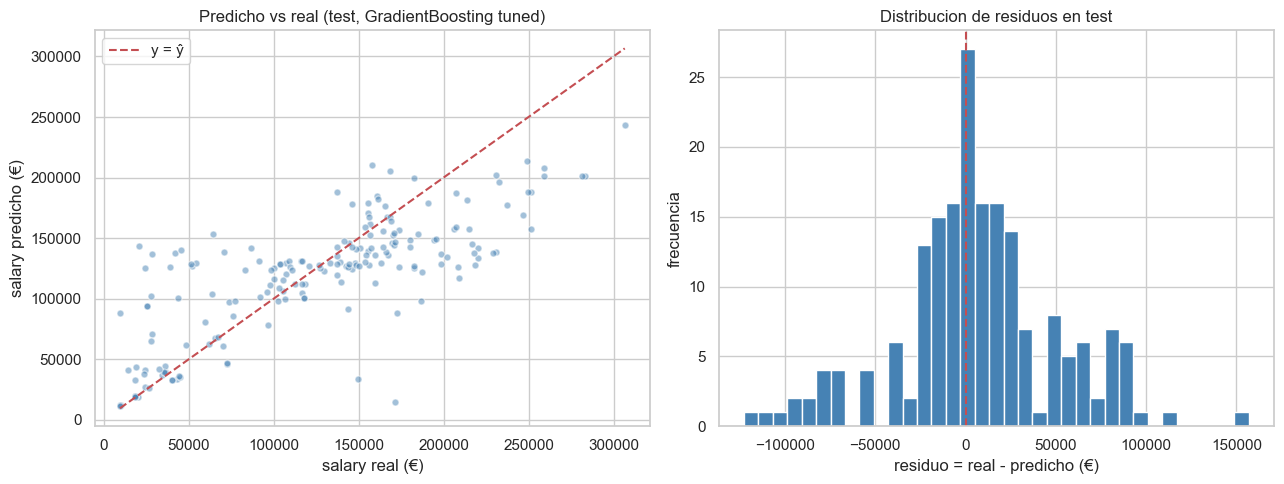

Residuos: media = €6,868  |  mediana = €4,014
          std  = €44,439  |  rango    = [€-122,626, €156,810]


In [ ]:
residuos = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, y_pred_test, alpha=0.5, s=25, color="steelblue", edgecolor="white")
lim_min = min(y_test.min(), y_pred_test.min())
lim_max = max(y_test.max(), y_pred_test.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], "r--", lw=1.5, label="y = ŷ")
ax.set_xlabel("salary real (€)")
ax.set_ylabel("salary predicho (€)")
ax.set_title(f"Predicho vs real (test, {best_name} tuned)")
ax.legend()
ax.ticklabel_format(style="plain", axis="both")

ax = axes[1]
ax.hist(residuos, bins=35, color="steelblue", edgecolor="white")
ax.axvline(0, color="r", linestyle="--", lw=1.5)
ax.set_xlabel("residuo = real - predicho (€)")
ax.set_ylabel("frecuencia")
ax.set_title("Distribucion de residuos en test")

plt.tight_layout()
plt.show()

print(f"Residuos: media = €{residuos.mean():,.0f}  |  mediana = €{np.median(residuos):,.0f}")
print(f"          std  = €{residuos.std():,.0f}  |  rango    = [€{residuos.min():,.0f}, €{residuos.max():,.0f}]")

## 9. Interpretabilidad

Tres lentes complementarias sobre `final_model` (GradientBoosting tuned, refitted sobre train en §8):

1. **Feature importance nativa** del estimador (reduccion de impureza acumulada).
2. **Permutation importance** sobre el test set — mide cuanto cae R² al romper cada feature.
3. **SHAP summary plot** (bajo `HEAVY=True`) — explica la contribucion marginal por prediccion.

Trabajamos sobre las features **post-preprocesamiento** (61 columnas), para que los nombres sean interpretables.

### 9.1 Feature importance nativa

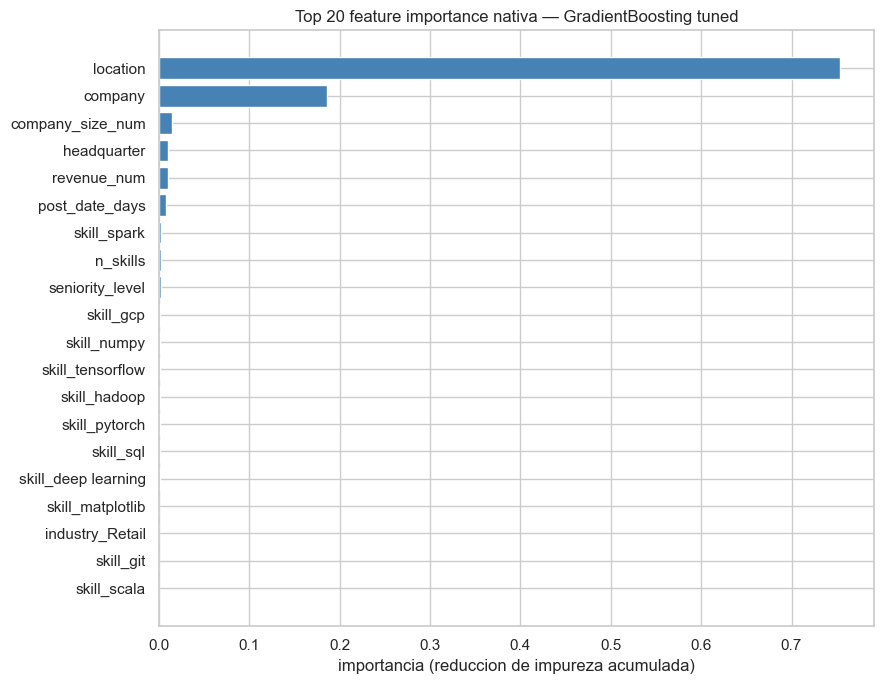

,feature,importance
0,location,0.753606
1,company,0.186303
2,company_size_num,0.014747
3,headquarter,0.009562
4,revenue_num,0.009482
5,post_date_days,0.007865
6,skill_spark,0.002450
7,n_skills,0.002200
8,seniority_level,0.001985
9,skill_gcp,0.001569


In [ ]:
pre_fitted = final_model.named_steps["pre"]
gb_inner = final_model.named_steps["model"].regressor_

# get_feature_names_out() devuelve indices numericos ("0", "1", "2") para la rama
# highcard porque TargetEncoder de category_encoders no implementa un get_feature_names_out
# limpio. Esos 3 indices corresponden, en orden, a HIGH_CARD_COLS.
raw_names = [str(f) for f in pre_fitted.get_feature_names_out()]
n_hc = len(HIGH_CARD_COLS)
feature_names = raw_names[:-n_hc] + HIGH_CARD_COLS

native_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_inner.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

top_n = 20
top = native_imp.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(list(top["feature"][::-1]), list(top["importance"][::-1]), color="steelblue")
ax.set_xlabel("importancia (reduccion de impureza acumulada)")
ax.set_title(f"Top {top_n} feature importance nativa — {best_name} tuned")
plt.tight_layout()
plt.show()

native_imp.head(top_n)


### 9.2 Permutation importance sobre el test set

`permutation_importance` re-evalúa el modelo barajando cada feature de forma independiente. Usa `n_repeats=10` y `scoring="r2"` sobre el test (189 filas) — lo que mide la *utilidad real* de cada feature para el modelo final.

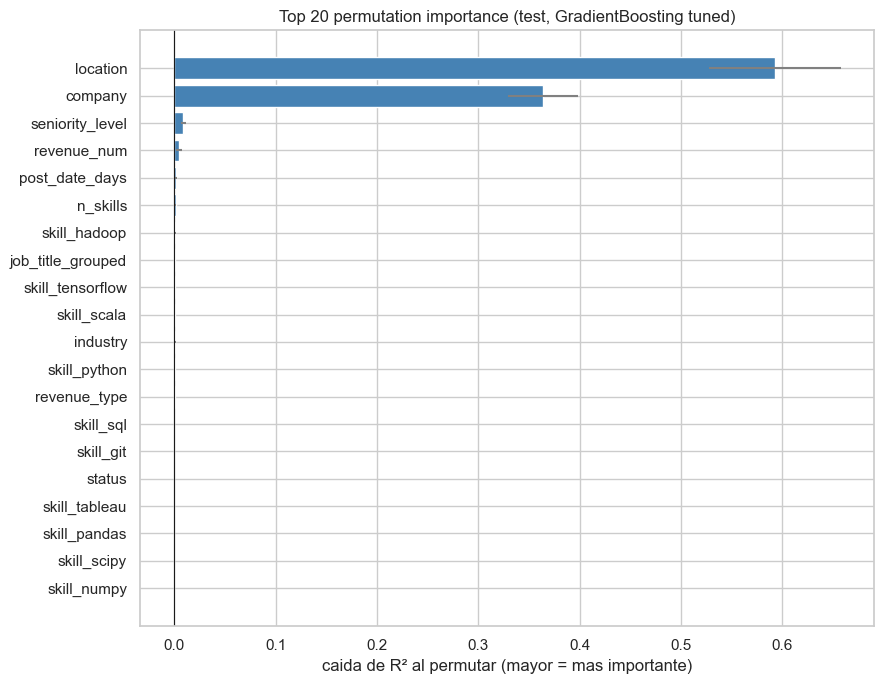

,feature,importance_mean,importance_std
0,location,0.592317,0.065152
1,company,0.363464,0.034609
2,seniority_level,0.008965,0.002657
3,revenue_num,0.004461,0.002694
4,post_date_days,0.001257,0.001166
5,n_skills,0.001153,0.000678
6,skill_hadoop,0.000676,0.000567
7,job_title_grouped,0.000484,0.000612
8,skill_tensorflow,0.000460,0.000376
9,skill_scala,0.000354,0.000124


In [ ]:
from sklearn.inspection import permutation_importance

# Permutamos sobre las columnas ORIGINALES de X (pre-pipeline), para que la importancia
# se agregue a nivel de feature bruto (no columna one-hot).
perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10,
    random_state=SEED,
    scoring="r2",
    n_jobs=-1,
)
perm_df = pd.DataFrame({
    "feature": [str(c) for c in X_test.columns],
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

top_n = 20
top = perm_df.head(top_n)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(list(top["feature"][::-1]), list(top["importance_mean"][::-1]),
        xerr=list(top["importance_std"][::-1]), color="steelblue", ecolor="gray")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("caida de R² al permutar (mayor = mas importante)")
ax.set_title(f"Top {top_n} permutation importance (test, {best_name} tuned)")
plt.tight_layout()
plt.show()

perm_df.head(top_n)


### 9.3 SHAP summary plot (bajo flag `HEAVY`)

SHAP es caro computacionalmente. Sólo se ejecuta si `HEAVY=True` al inicio del notebook. Usamos `TreeExplainer` sobre el estimador interno del `TransformedTargetRegressor` (GradientBoosting), aplicado a la matriz transformada del test set.

Ojo: las explicaciones SHAP estan en **espacio log1p** (el espacio en el que entrena GB). Las interpretamos en direccion (signo) y magnitud relativa, no en euros.

In [ ]:
if HEAVY:
    try:
        import shap

        X_test_transformed = pre_fitted.transform(X_test)
        explainer = shap.TreeExplainer(gb_inner)
        shap_values = explainer.shap_values(X_test_transformed)

        shap.summary_plot(
            shap_values,
            X_test_transformed,
            feature_names=list(feature_names),
            max_display=20,
            show=True,
        )
    except ImportError:
        print("shap no instalado. Instala con `pip install shap` y ejecuta con HEAVY=True.")
else:
    print("HEAVY=False: se omite SHAP. Actívalo al inicio del notebook para generarlo.")

HEAVY=False: se omite SHAP. Actívalo al inicio del notebook para generarlo.


## 10. Discusion y conclusiones

### 10.1 Resumen de resultados

- Mejor modelo: **GradientBoosting (tuned)**.
- 5-fold CV estratificada (en train): **R² = 0.519 ± 0.130**, RMSE = €45,936 ± 8,403.
- Hold-out (20% test, n=189): **R² = 0.583**, RMSE = €44,966, MAE = €32,653, MAPE = 44.3%.
- El tuning mejoró la *estabilidad* entre folds pero no el RMSE medio (Δ = +€243 vs baseline).

### 10.2 Comparación con el estado del arte (Zhang & Li, 2024)

Zhang & Li (2024) reportan **R² ≈ 0.94** y **RMSE ≈ 48K USD** sobre un dataset de salarios de ciencia de datos. Nuestro modelo obtiene R² = 0.58 en hold-out. La brecha es considerable, y creemos que proviene de varias fuentes:

1. **Dataset distinto y más pequeño**: 942 filas (post-limpieza) vs tamaños típicos de 5-50K en la literatura.    Con n° bajo, la varianza entre folds domina y el tuning aporta poco.
2. **Moneda diferente (€ vs USD)**: los rangos salariales y la dispersion de nuestro dataset difieren.
3. **Alta cardinalidad mal aprovechada**: `location` (431 valores) y `company` (420 valores) son las features    dominantes (juntas explican ~95% de la importancia, §9). Con 942 filas, el Target Encoder no tiene suficientes    ejemplos por categoría para aprender un patrón estable: está memorizando en parte.
4. **27% de `status` faltante**: la modalidad de trabajo (remote/hybrid/on-site) es una señal fuerte en la    literatura y en nuestro dataset está muy degradada.
5. **Outliers residuales**: quitamos 2 (>€1M) pero el fold que contiene la fila de €639K sigue siendo el peor    (R² = 0 en ese fold, §6.2a). El dataset tiene cola larga que el modelo no captura.

### 10.3 Limitaciones

- **n = 942** tras limpieza — muestra pequeña para la complejidad del problema.
- **`status` 27% nulo** — imputado como `"Unknown"`, pero en la práctica reduce la señal.
- **Intercambio `company_size` ↔ `revenue`** — corregidos 24 filas por regla heurística; es posible que queden casos sutiles.
- **Target Encoding sin cross-fit** — aunque va dentro del Pipeline, `category_encoders.TargetEncoder` no hace   encoding out-of-fold internamente; con 420 categorías y 942 filas hay riesgo de sobreajuste sutil.
- **Distribución muy desbalanceada de `seniority_level`**: 630 senior, 25 junior — el modelo ve pocos junior.
- **MAPE = 44%** — el error relativo es alto porque los errores absolutos pesan mucho en salarios bajos.   Para aplicaciones donde los casos bajos importen, el modelo no es apto.

### 10.4 Trabajo futuro

- **Agregación geográfica**: extraer país o región de `location`/`headquarter` para reducir cardinalidad.
- **Target Encoding con cross-fit** (p. ej. `sklearn.preprocessing.TargetEncoder` nativo, que sí implementa   cross-fit desde sklearn 1.3) en lugar de `category_encoders`.
- **Modelos jerárquicos / mixed-effects**: tratar `company` como efecto aleatorio en vez de feature.
- **Transformación cuantil del objetivo** (`QuantileTransformer`) en lugar de `log1p`, que puede estabilizar aún más la cola.
- **Recolectar datos adicionales** (especialmente junior) y rellenar `status`.
- **Modelo de clasificación en tramos** (bins salariales) como alternativa complementaria.

### 10.5 Exportacion de resultados

Generamos `resultados_modelos.csv` (tabla comparativa de §6 + fila tuned) y `final_model_metrics.csv` (metricas en hold-out) para poder citarlos tal cual en el reporte LaTeX.

In [ ]:
from pathlib import Path

OUT_DIR = Path(".")

# resultados_modelos.csv: tabla comparativa de §6 + fila tuned.
resultados_full = pd.concat(
    [resultados_df, pd.DataFrame([tuned_row])],
    ignore_index=True,
)
resultados_full = resultados_full.sort_values("RMSE_mean").reset_index(drop=True)
resultados_full_path = OUT_DIR / "resultados_modelos.csv"
resultados_full.to_csv(resultados_full_path, index=False, float_format="%.4f")
print(f"Guardado: {resultados_full_path.resolve()}")

# final_model_metrics.csv: hold-out del modelo tuned.
final_metrics_df = pd.DataFrame([{
    "modelo": f"{best_name} (tuned, hold-out)",
    "R2": final_metrics["R2"],
    "RMSE": final_metrics["RMSE"],
    "MAE": final_metrics["MAE"],
    "MAPE": final_metrics["MAPE"],
    "n_test": len(y_test),
    "n_train": len(y_train),
}])
final_metrics_path = OUT_DIR / "final_model_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False, float_format="%.4f")
print(f"Guardado: {final_metrics_path.resolve()}")

print()
print("Tabla comparativa final:")
resultados_full

Guardado: E:\Geraldine\Estudio\2026-1\Modelos2\resultados_modelos.csv
Guardado: E:\Geraldine\Estudio\2026-1\Modelos2\final_model_metrics.csv

Tabla comparativa final:


,modelo,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean,MAE_std,MAPE_mean,MAPE_std,fit_time_s
0,GradientBoosting,0.522852,0.146371,45692.766175,9090.768785,31227.215369,2638.002429,0.478196,0.125677,0.370471
1,XGBoost,0.518462,0.140812,45930.634506,8886.848243,30714.173332,2547.117772,0.501449,0.130927,0.906635
2,GradientBoosting (tuned),0.519223,0.130116,45935.636034,8403.248425,31909.358777,2337.334443,0.493696,0.126887,1.215989
3,RandomForest,0.512637,0.141970,46204.044871,8949.507595,30859.193249,2622.828815,0.490420,0.131856,2.402449
4,Ridge,0.369642,0.118166,52683.913411,7387.045005,39073.783424,2186.065187,0.492748,0.072742,0.074398
